In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [40]:
df = pd.read_csv("/content/Cars_data_.csv")

In [41]:
print(df.head())

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

In [42]:
print(df.dtypes)
print("\nNumber of records in each column:")
print(df.count())

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

Number of records in each column:
Make                 11914
Model                11914
Year                 11914
Engine Fuel Type     11911
Engine HP            11845
Engine Cylinders     11884
Transmission Type    11914
Driven_Wheels        11914
Number of Doors      11908
Market Category       8172
Vehicle Size         11914
Vehicle Style        11914
highway MPG          11914
city mpg             11914
Popularity           11914
MSRP                 11914
dtype: int64


In [43]:
cols_to_drop = [
    "Engine Fuel Type",
    "Market Category",
    "Vehicle Style",
    "Popularity",
    "Number of Doors",
    "Vehicle Size"
]

In [44]:
df = df.drop(columns = cols_to_drop)
print(df.head())

  Make       Model  Year  Engine HP  Engine Cylinders Transmission Type  \
0  BMW  1 Series M  2011      335.0               6.0            MANUAL   
1  BMW    1 Series  2011      300.0               6.0            MANUAL   
2  BMW    1 Series  2011      300.0               6.0            MANUAL   
3  BMW    1 Series  2011      230.0               6.0            MANUAL   
4  BMW    1 Series  2011      230.0               6.0            MANUAL   

      Driven_Wheels  highway MPG  city mpg   MSRP  
0  rear wheel drive           26        19  46135  
1  rear wheel drive           28        19  40650  
2  rear wheel drive           28        20  36350  
3  rear wheel drive           28        18  29450  
4  rear wheel drive           28        18  34500  


In [45]:
rename_cols = {
    "Engine HP": "HP",
    "Engine Cylinders": "Cylinders",
    "Tranmission Type": "Transmission",
    "Driven_Wheels": "Driven mode",
    "highway MPG": "MPG-H",
    "city mpg": "MPG-C",
    "MSRP": "Price"
}

In [46]:
df = df.rename(columns = rename_cols)
print(df.head())

  Make       Model  Year     HP  Cylinders Transmission Type  \
0  BMW  1 Series M  2011  335.0        6.0            MANUAL   
1  BMW    1 Series  2011  300.0        6.0            MANUAL   
2  BMW    1 Series  2011  300.0        6.0            MANUAL   
3  BMW    1 Series  2011  230.0        6.0            MANUAL   
4  BMW    1 Series  2011  230.0        6.0            MANUAL   

        Driven mode  MPG-H  MPG-C  Price  
0  rear wheel drive     26     19  46135  
1  rear wheel drive     28     19  40650  
2  rear wheel drive     28     20  36350  
3  rear wheel drive     28     18  29450  
4  rear wheel drive     28     18  34500  


In [47]:
print("Number of rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates()
print(df.head())

Number of rows before removing duplicates: 11914
  Make       Model  Year     HP  Cylinders Transmission Type  \
0  BMW  1 Series M  2011  335.0        6.0            MANUAL   
1  BMW    1 Series  2011  300.0        6.0            MANUAL   
2  BMW    1 Series  2011  300.0        6.0            MANUAL   
3  BMW    1 Series  2011  230.0        6.0            MANUAL   
4  BMW    1 Series  2011  230.0        6.0            MANUAL   

        Driven mode  MPG-H  MPG-C  Price  
0  rear wheel drive     26     19  46135  
1  rear wheel drive     28     19  40650  
2  rear wheel drive     28     20  36350  
3  rear wheel drive     28     18  29450  
4  rear wheel drive     28     18  34500  


In [48]:
print("Number of rows after removing Duplicates:", df.shape[0])

print(df.isnull().sum())
df = df.dropna()

Number of rows after removing Duplicates: 10925
Make                  0
Model                 0
Year                  0
HP                   69
Cylinders            30
Transmission Type     0
Driven mode           0
MPG-H                 0
MPG-C                 0
Price                 0
dtype: int64


In [49]:
print(df.isnull().sum())

Make                 0
Model                0
Year                 0
HP                   0
Cylinders            0
Transmission Type    0
Driven mode          0
MPG-H                0
MPG-C                0
Price                0
dtype: int64


In [50]:
print(df.describe())

               Year            HP     Cylinders         MPG-H         MPG-C  \
count  10827.000000  10827.000000  10827.000000  10827.000000  10827.000000   
mean    2010.896370    254.553062      5.691604     26.308119     19.327607   
std        7.029534    109.841537      1.768551      7.504652      6.643567   
min     1990.000000     55.000000      0.000000     12.000000      7.000000   
25%     2007.000000    173.000000      4.000000     22.000000     16.000000   
50%     2015.000000    240.000000      6.000000     25.000000     18.000000   
75%     2016.000000    303.000000      6.000000     30.000000     22.000000   
max     2017.000000   1001.000000     16.000000    354.000000    137.000000   

              Price  
count  1.082700e+04  
mean   4.249325e+04  
std    6.229451e+04  
min    2.000000e+03  
25%    2.197250e+04  
50%    3.084500e+04  
75%    4.330000e+04  
max    2.065902e+06  


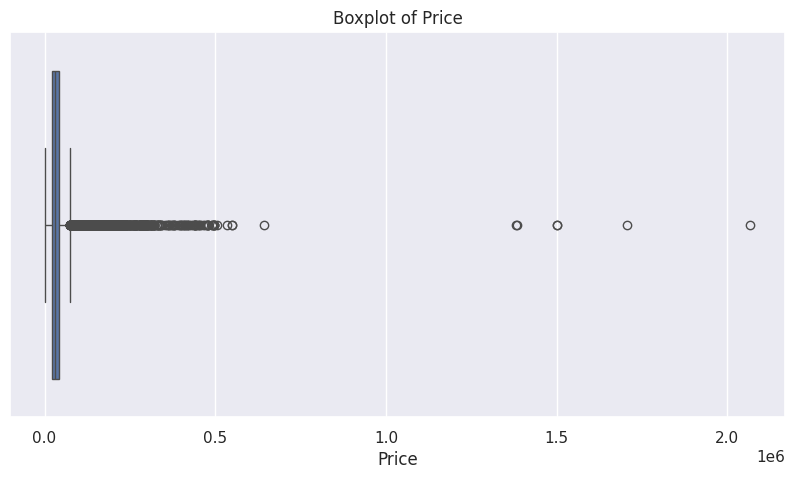

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

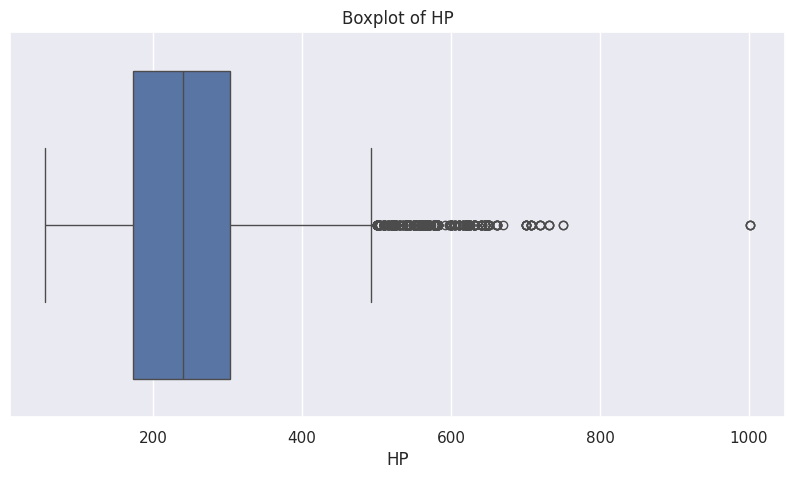

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['HP'])
plt.title("Boxplot of HP")
plt.show()

In [53]:
print(df.loc[:, df.dtypes.isin(["int64", "float64"])].columns)

Index(['HP', 'Cylinders'], dtype='object')


In [54]:
l = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(l)

['Year', 'HP', 'Cylinders', 'MPG-H', 'MPG-C', 'Price']


In [55]:
Q1 = df[l].quantile(0.25)
Q3 = df[l].quantile(0.75)
IQR = Q3 - Q1

df2 = df[~((df[l] < (Q1 - 1.5 * IQR)) |
           (df[l] > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df2.head())

  Make       Model  Year     HP  Cylinders Transmission Type  \
0  BMW  1 Series M  2011  335.0        6.0            MANUAL   
1  BMW    1 Series  2011  300.0        6.0            MANUAL   
2  BMW    1 Series  2011  300.0        6.0            MANUAL   
3  BMW    1 Series  2011  230.0        6.0            MANUAL   
4  BMW    1 Series  2011  230.0        6.0            MANUAL   

        Driven mode  MPG-H  MPG-C  Price  
0  rear wheel drive     26     19  46135  
1  rear wheel drive     28     19  40650  
2  rear wheel drive     28     20  36350  
3  rear wheel drive     28     18  29450  
4  rear wheel drive     28     18  34500  


In [56]:
print("Shape of the original dataframe:", df.shape)
print("Shape of the removing dataframe:", df2.shape)

Shape of the original dataframe: (10827, 10)
Shape of the removing dataframe: (9191, 10)


In [57]:
for i in df.columns:
  print("----------------%s-----------------" % i)
  print(df[i].value_counts())

----------------Make-----------------
Make
Chevrolet        1043
Ford              798
Toyota            651
Volkswagen        563
Nissan            540
Dodge             513
GMC               475
Honda             429
Cadillac          396
Mazda             392
Mercedes-Benz     340
Suzuki            338
Infiniti          326
BMW               324
Audi              320
Hyundai           254
Acura             246
Volvo             241
Subaru            229
Kia               219
Mitsubishi        202
Lexus             201
Chrysler          185
Buick             184
Pontiac           163
Lincoln           152
Porsche           134
Land Rover        126
Oldsmobile        111
Saab              101
Aston Martin       91
Bentley            74
Ferrari            69
Plymouth           62
Scion              60
FIAT               58
Maserati           55
Lamborghini        52
Rolls-Royce        31
Lotus              28
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren    

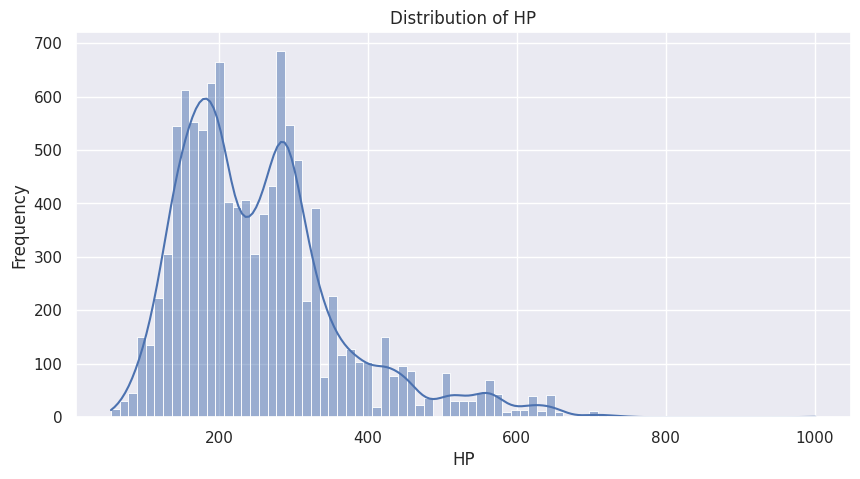

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(df["HP"], kde=True)
plt.title("Distribution of HP")
plt.xlabel("HP")
plt.ylabel("Frequency")
plt.show()

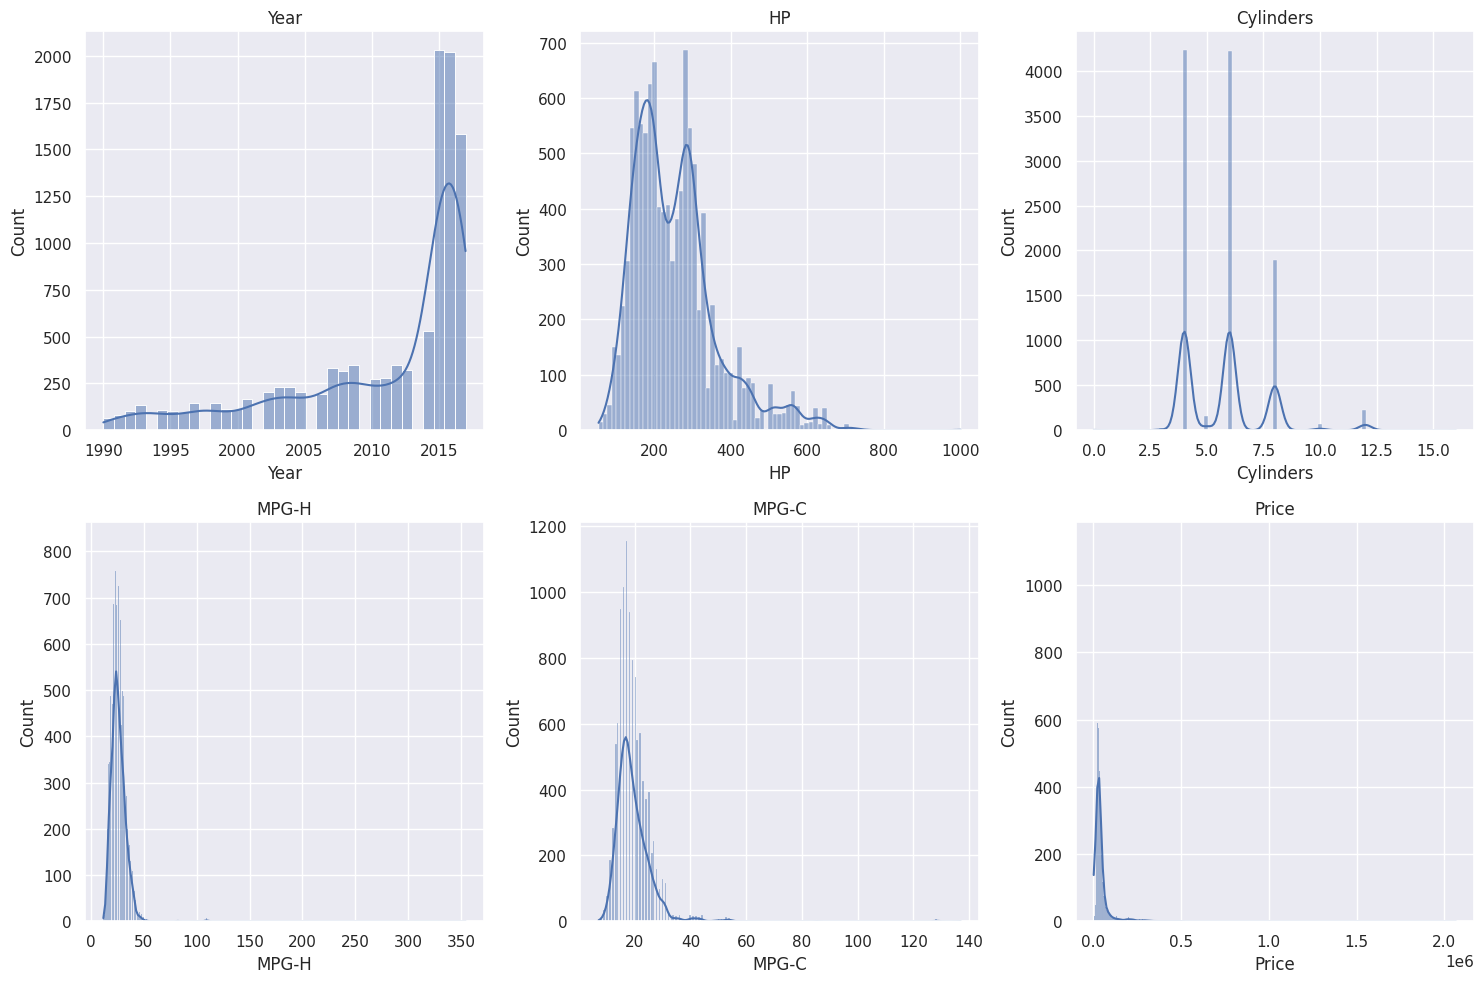

In [59]:
c = 0

plt.figure(figsize=(15, 10))

for i in l:
  c += 1
  plt.subplot(2, 3,c)
  sns.histplot(df[i], kde=True)
  plt.title(i)

plt.tight_layout()
plt.show()

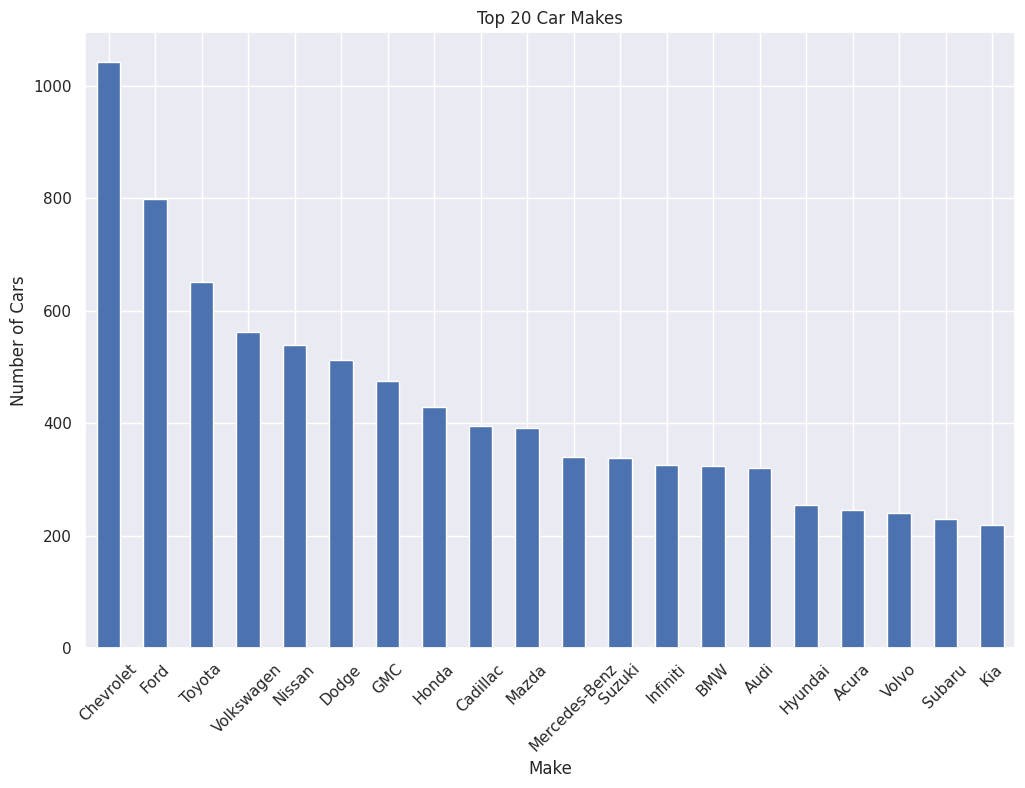

In [60]:
plt.figure(figsize=(12, 8))

df["Make"].value_counts().nlargest(20).plot(kind="bar")

plt.title("Top 20 Car Makes")
plt.xlabel("Make")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.show()

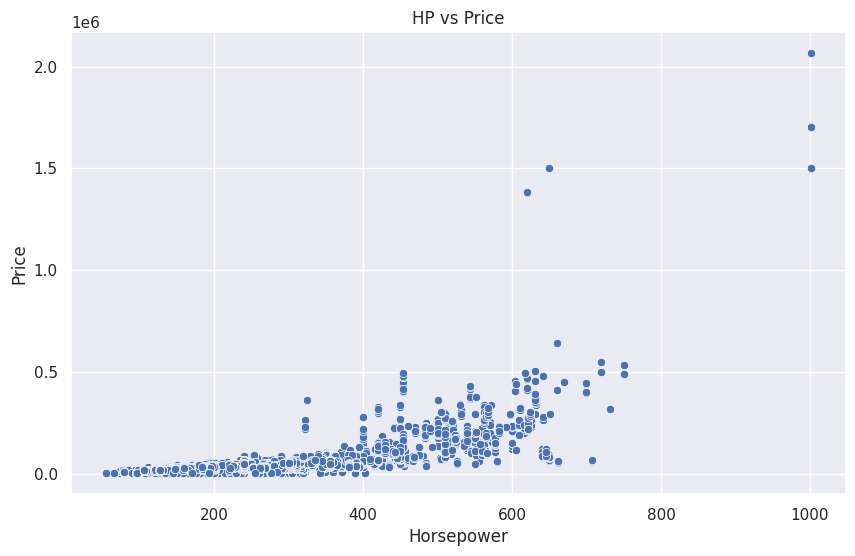

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HP",
    y="Price"
)

plt.title("HP vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()


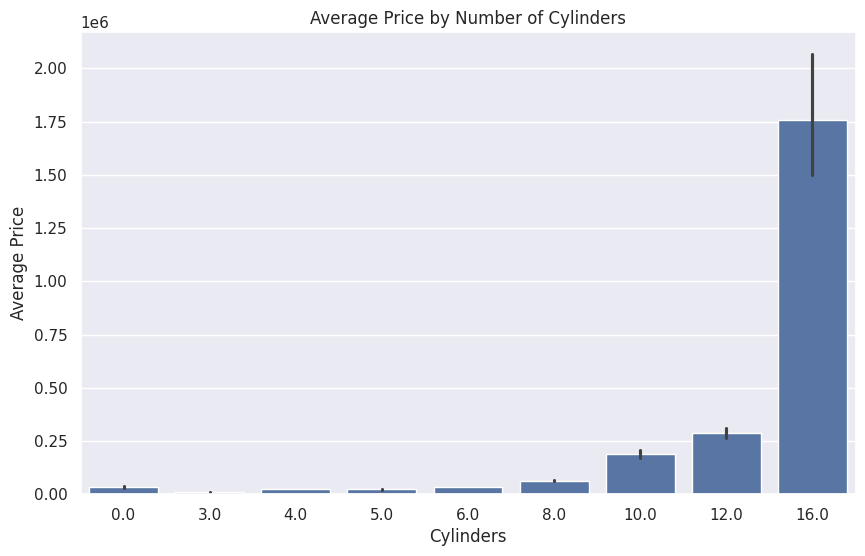

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Cylinders",
    y="Price"
)

plt.title("Average Price by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average Price")
plt.show()

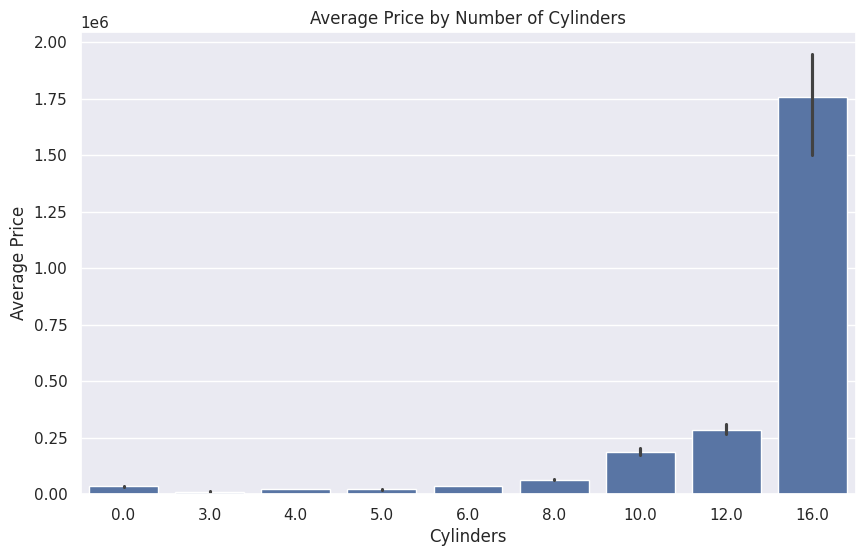

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Cylinders",
    y="Price"
)

plt.title("Average Price by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average Price")
plt.show()

In [67]:
corr = df.corr(numeric_only=True)

print(corr)

               Year        HP  Cylinders     MPG-H     MPG-C     Price
Year       1.000000  0.314971  -0.050598  0.284237  0.234135  0.196789
HP         0.314971  1.000000   0.788007 -0.420281 -0.473551  0.659835
Cylinders -0.050598  0.788007   1.000000 -0.611576 -0.632407  0.554740
MPG-H      0.284237 -0.420281  -0.611576  1.000000  0.841229 -0.209150
MPG-C      0.234135 -0.473551  -0.632407  0.841229  1.000000 -0.234050
Price      0.196789  0.659835   0.554740 -0.209150 -0.234050  1.000000


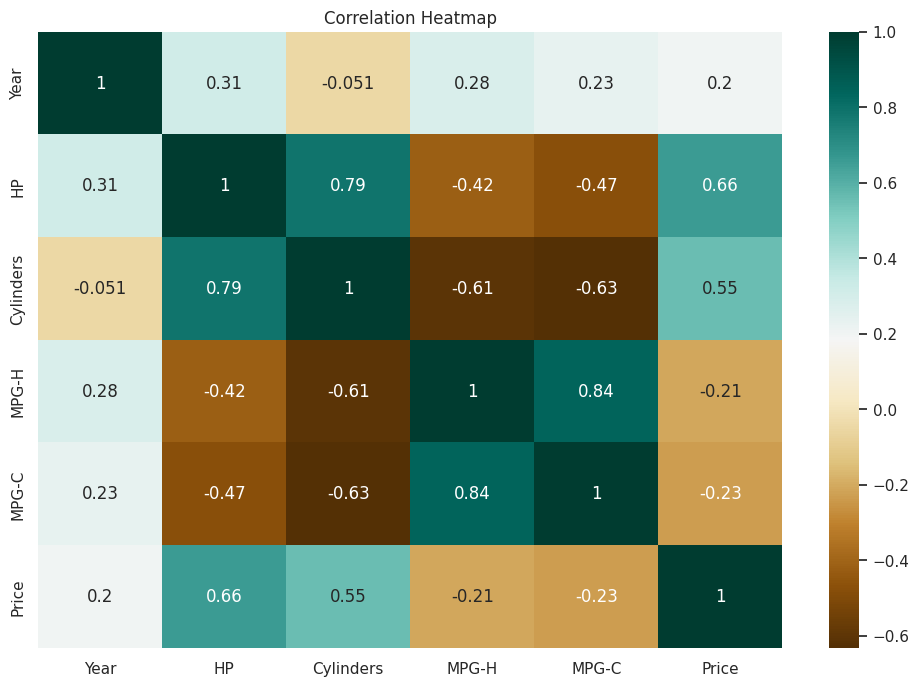

In [68]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap="BrBG",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()